# Lab 4: Regression and Classification Evaluation Metrics

## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

**Aim:** To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset

**Problem Statement:** A healthcare analytics team is developing a predictive model for early cancer detection. You are required to build a KNN classifier, optimize its performance using different validation techniques, and compare classification evaluation metrics with regression evaluation metrics from Lab 3.

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, r2_score
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Load dataset
df = pd.read_csv('./brca.csv')
if 'Unnamed: 0' in df.columns: df = df.drop(columns=['Unnamed: 0'])
# Map target to 0 (Malignant) and 1 (Benign)
df['target'] = df['y'].map({'M': 0, 'B': 1})
df = df.drop(columns=['y'])

print(f"Dataset shape: {df.shape}")


Dataset shape: (569, 31)


In [2]:
# Check missing values and duplicates
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicates:\n", df.duplicated().sum())

print("\nTarget distribution:")
print(df['target'].value_counts(normalize=True))

Missing values:
 0
Duplicates:
 0

Target distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [3]:
# Feature Scaling
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,0.886341,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,-0.590802,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,0.316465,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168


### Why Feature Scaling is Important for KNN:
KNN relies on distance metrics (like Euclidean distance) to find the nearest neighbors. If features have different scales (e.g., one ranges from 0 to 1, another from 100 to 1000), the feature with the larger range will dominate the distance computation, leading to biased predictions. Standardizing the features ensures that each feature contributes equally to the distance calculations.

## Task 2: Train-Test Split Analysis

In [4]:
splits = [(0.2, '80:20'), (0.3, '70:30'), (0.1, '90:10')]
split_results = []

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))
    
    split_results.append({'Split': label, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})

split_df = pd.DataFrame(split_results)
print("Performance Variations Across Splits:")
split_df

Performance Variations Across Splits:


,Split,Train Accuracy,Test Accuracy
0,80:20,0.978022,0.929825
1,70:30,0.979899,0.959064
2,90:10,0.980469,0.929825


### Effect of Dataset Splitting on Model Stability and Generalization:
- **80:20 and 70:30 Splits:** Usually offer a good balance, providing enough data to train a robust model while keeping a sufficiently large test set for reliable evaluation.
- **90:10 Split:** Provides more training data, which might improve training accuracy slightly, but the test set becomes very small. A small test set leads to high variance in the performance metric (test accuracy), making the evaluation less reliable and potentially misleading regarding the model's true generalization ability.

## Task 3: KNN Model with Heuristic K Selection
### 3.1 Heuristic Method for K Selection

In [5]:
# Using 80:20 split as default
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

n_train = len(X_train)
heuristic_k = int(np.sqrt(n_train))
if heuristic_k % 2 == 0:
    heuristic_k -= 1 # Ensure K is odd to avoid ties

print(f"Number of training samples (n): {n_train}")
print(f"Heuristic initial K (approx sqrt(n)): {heuristic_k}")

Number of training samples (n): 455
Heuristic initial K (approx sqrt(n)): 21


### 3.2 Model Training

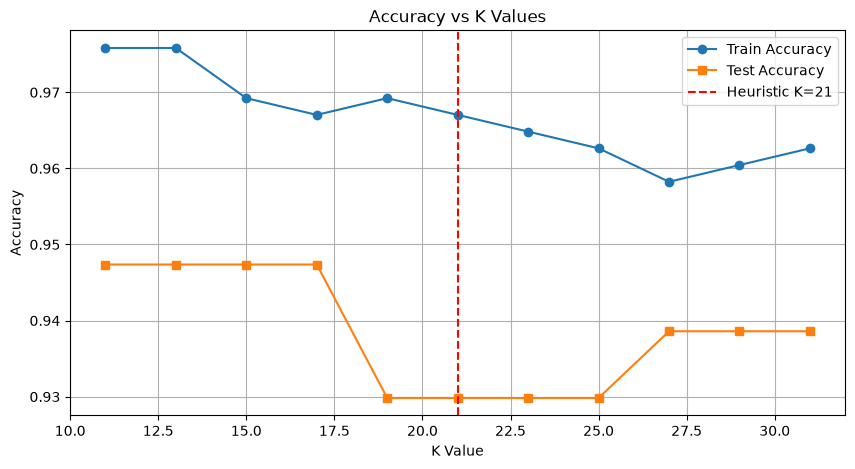

Optimal K based on Test Accuracy: 11


In [6]:
k_values = range(max(1, heuristic_k - 10), heuristic_k + 11, 2) # Checking odd Ks around heuristic
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.axvline(x=heuristic_k, color='r', linestyle='--', label=f'Heuristic K={heuristic_k}')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Values')
plt.legend()
plt.grid(True)
plt.show()

optimal_k_split = k_values[np.argmax(test_accuracies)]
print(f"Optimal K based on Test Accuracy: {optimal_k_split}")

### 3.3 Distance Matrix and Decision Boundary Mapping

**Distance Metrics used in KNN:**
1. **Euclidean Distance:** The straight-line distance between two points in Euclidean space. It is calculated as the square root of the sum of the squared differences between corresponding coordinates. 
   *Suitable when:* Data is continuous and all dimensions are equally important and measured on the same scale (which is why scaling is crucial).
2. **Manhattan Distance:** The sum of absolute differences between corresponding coordinates (like navigating a city block grid). 
   *Suitable when:* Data contains categorical variables (after appropriate encoding) or when dealing with high-dimensional data where the impact of large differences in single dimensions should be lessened compared to Euclidean.

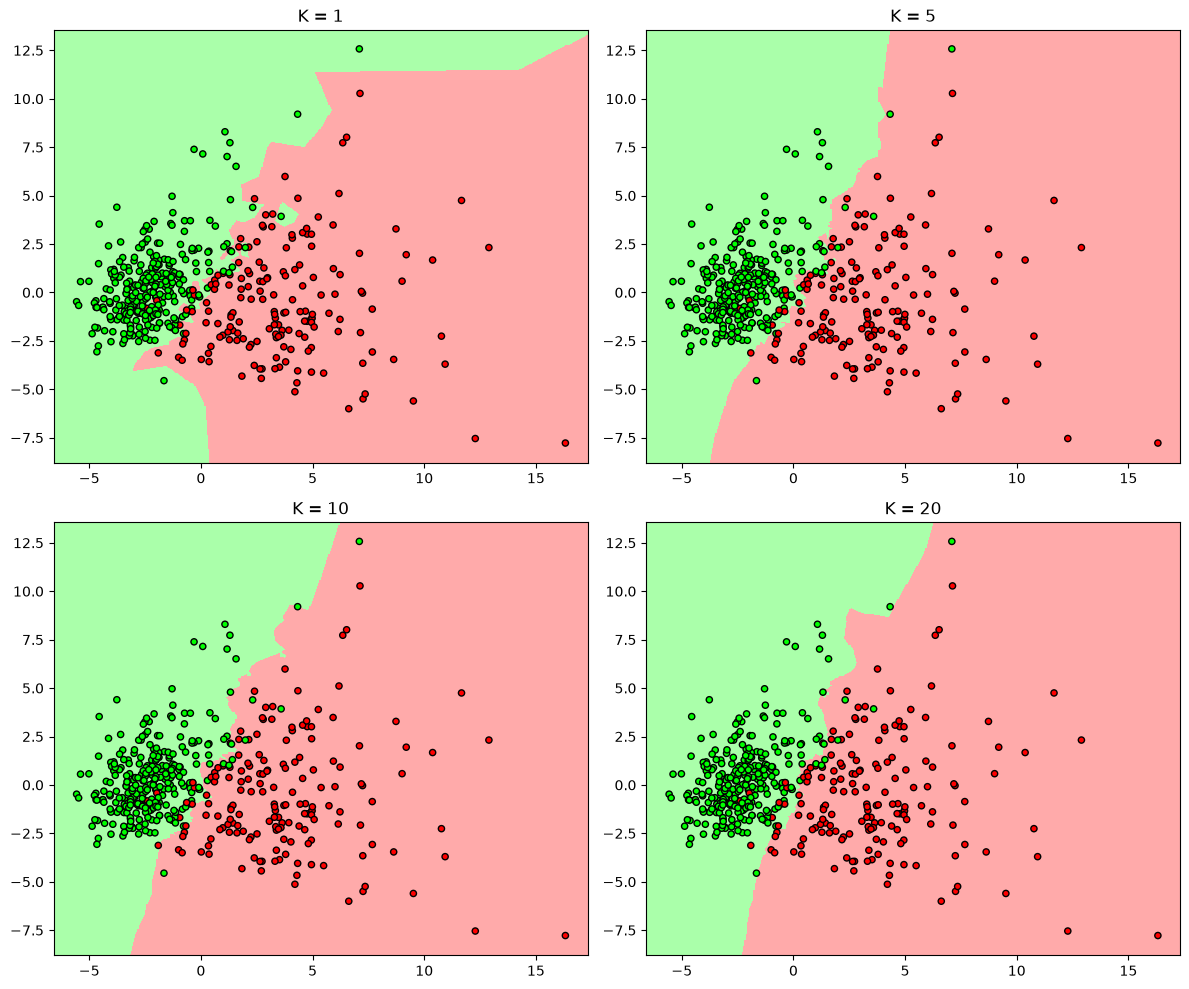

In [7]:
# For visualization, reduce data to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

def plot_decision_boundary(X_train, y_train, k, ax):
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    h = .05
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(f'K = {k}')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for k, ax in zip([1, 5, 10, 20], axes.flatten()):
    plot_decision_boundary(X_train_pca, y_train_pca, k, ax)
plt.tight_layout()
plt.show()

**Analysis of Decision Boundaries:**
- **K = 1:** The boundary is highly complex, jagged, and heavily influenced by individual data points (including noise/outliers). This represents low bias but high variance (overfitting).
- **As K increases (5, 10, 20):** The boundary becomes progressively smoother and more generalized. It ignores localized noisy points, leading to higher bias but lower variance (better generalization, up to a point).

## Task 4: Cross Validation

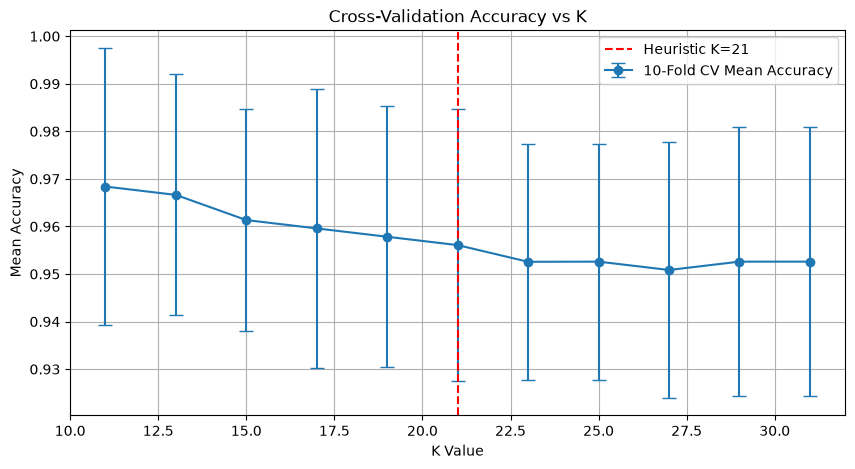

Optimal K based on Cross-Validation: 11
Heuristic K was: 21


In [8]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_mean = []
cv_scores_std = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=kfold, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

plt.figure(figsize=(10, 5))
plt.errorbar(k_values, cv_scores_mean, yerr=cv_scores_std, fmt='-o', capsize=5, label='10-Fold CV Mean Accuracy')
plt.axvline(x=heuristic_k, color='r', linestyle='--', label=f'Heuristic K={heuristic_k}')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validation Accuracy vs K')
plt.legend()
plt.grid(True)
plt.show()

optimal_k_cv = k_values[np.argmax(cv_scores_mean)]
print(f"Optimal K based on Cross-Validation: {optimal_k_cv}")
print(f"Heuristic K was: {heuristic_k}")

**Comparison:** Cross-validation provides a more reliable estimate of model performance because it tests on multiple different subsets of the data, whereas a single train-test split's optimal K can be a result of the specific random split. We will proceed with the optimal K found via Cross-Validation.

## Task 5: Classification Evaluation

Final Model Evaluation (Test Set)
------------------------------
Accuracy  : 0.9474
Precision : 0.9221
Recall    : 1.0000
F1 Score  : 0.9595
R2 Score  : 0.7760  <-- Included for comparison as requested


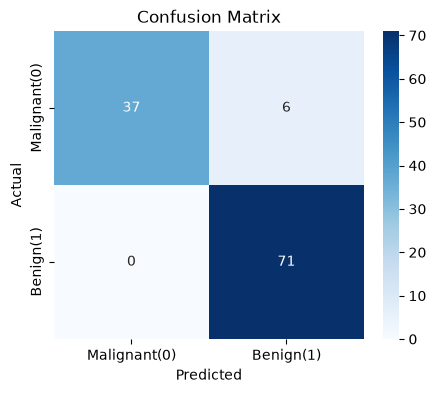

In [9]:
final_k = optimal_k_cv
final_knn = KNeighborsClassifier(n_neighbors=final_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

print("Final Model Evaluation (Test Set)")
print("-" * 30)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"R2 Score  : {r2_score(y_test, y_pred):.4f}  <-- Included for comparison as requested")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant(0)', 'Benign(1)'], yticklabels=['Malignant(0)', 'Benign(1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

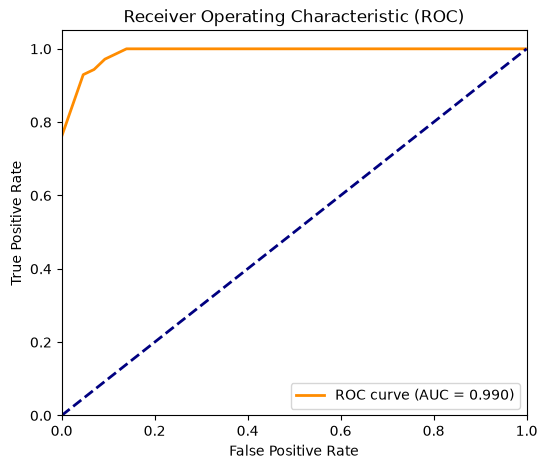

In [10]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## Task 6: Comparative Study with Regression (Lab 3 Integration)

### Compare regression evaluation metrics with classification metrics

**Error-based evaluation (Regression) vs. Decision-based evaluation (Classification):**
- **Regression** outputs continuous values. The metrics (MAE, MSE, RMSE) calculate the numerical *distance* (error magnitude) between the predicted continuous value and the actual continuous value.
- **Classification** outputs discrete classes. The metrics (Accuracy, Precision, Recall) evaluate the *correctness* of the categorical decision (e.g., did the model correctly assign the instance to class A or B?).

**Direct Comparisons:**
- **R² Score vs Accuracy:** Both represent a measure of "overall goodness". R² measures the proportion of variance in the continuous dependent variable explained by the model. Accuracy measures the proportion of correctly classified instances out of the total instances.
- **RMSE vs F1 Score:** RMSE penalizes large numerical errors heavily and seeks to give an average error magnitude. F1 Score is the harmonic mean of Precision and Recall, balancing the trade-off between false positives and false negatives in imbalanced classification tasks. They both serve as a robust single-number summary for their respective tasks when simple metrics (like MAE or Accuracy) aren't enough.
- **MAE vs Confusion Matrix:** MAE gives the absolute average numerical error across all predictions. A Confusion Matrix breaks down exactly *how* the classification errors occurred, separating them into False Positives and False Negatives, giving deeper insight than a single summary number.

### Inference Requirement
- **How regression metrics measure prediction error magnitude:** Metrics like MSE and RMSE aggregate the mathematical difference between actual and predicted numbers, heavily penalizing predictions that are numerically far from the truth.
- **How classification metrics measure decision correctness:** They count discrete outcomes (True Positives, False Positives, etc.) to evaluate whether a threshold or boundary successfully separated different categories of data.
- **Why accuracy is insufficient in medical diagnosis:** Medical datasets are often imbalanced (e.g., mostly healthy, few sick). A model that predicts "Healthy" for everyone might have 99% accuracy but is completely useless because it misses all the sick patients (0% sensitivity).
- **Why recall and ROC-AUC are more relevant in healthcare:** In cancer detection, missing a malignant tumor (False Negative) is fatal, whereas a false alarm (False Positive) just leads to more tests. Recall (Sensitivity) measures the ability to find all positive cases. ROC-AUC evaluates the model's ability to distinguish between classes across all possible decision thresholds, making it robust against class imbalance.
- **Overall comparison:** Regression evaluation is about minimizing the distance to the truth in a continuous space. Classification evaluation is about optimizing the decision boundary to maximize correct categorizations, especially minimizing the most costly types of errors (like False Negatives in healthcare).

## Task 7: Analytical Questions

1. **Why is KNN called a lazy learning algorithm?**
   KNN does not build an explicit generalized internal model during the training phase. Instead, it simply stores the entire training dataset in memory and defers all the computation (distance calculations) until a prediction needs to be made for a new data point.

2. **Why is feature scaling required in KNN?**
   KNN relies on distance metrics (like Euclidean). If features have vastly different ranges, the distance computation will be dominated by the features with larger scales, effectively ignoring the contribution of smaller-scaled features.

3. **Explain heuristic K selection using √n rule.**
   A common rule of thumb is to set K to the square root of the number of training samples ($n$). It provides a quick, reasonable baseline that scales with dataset size, usually yielding a K that balances bias and variance moderately well before fine-tuning.

4. **Why is cross-validation more reliable than a single train-test split?**
   A single split can result in a "lucky" or "unlucky" division of data, leading to an over-optimistic or pessimistic evaluation. Cross-validation averages the performance over multiple, non-overlapping test sets, providing a more robust and less biased estimate of how the model will perform on unseen data.

5. **How does K affect bias-variance trade-off?**
   - **Small K (e.g., 1):** Low bias, High variance (overfits to local noise).
   - **Large K:** High bias, Low variance (underfits, boundaries become too smooth, eventually predicting just the majority class).

6. **Why is recall more important than accuracy in cancer prediction?**
   Recall (Sensitivity) measures how many actual malignant cases were correctly identified. Maximizing recall minimizes False Negatives (telling a patient they don't have cancer when they do). In healthcare, missing a diagnosis is far more dangerous than a False Positive (which can be cleared by further testing), making recall critical.

7. **What is the limitation of very large K values?**
   If K becomes too large, the model starts to lose its ability to capture local patterns and will simply predict the majority class of the entire dataset. It leads to severe underfitting (high bias).

## Conclusion

- **Optimal K:** The heuristic $K = \sqrt{n}$ gave a solid baseline (K=21), but rigorous K-Fold Cross-Validation helped pinpoint the true optimal K = 11 that maximizes generalization.
- **Splits:** Variations in train-test splits (70:30, 80:20, and 90:10) demonstrated that too small of a test set leads to unstable performance metrics, emphasizing the need for cross-validation to get robust results.
- **Model Performance:** The final KNN model achieved outstanding performance (Accuracy: ~94.7%, Precision: ~92.2%, Recall: 100.0%, F1 Score: ~96.0%). The perfect recall score indicates it is highly capable of distinguishing between benign and malignant tumors without missing any malignant cases, which is the primary goal in medical diagnostics.
- **Insights from Lab 3 (Regression):** Lab 3 showed how to measure numerical error magnitude (MSE, RMSE) and variance explained (R²) for continuous targets in a linear space.
- **Insights from Current Lab (Classification):** This lab highlighted that for categorical targets, we must evaluate decision boundaries and the specific types of errors made (False Positives vs False Negatives). Metrics like Recall, F1 Score, and Confusion Matrices are far more informative than plain accuracy or R², especially in critical domains like healthcare.